# Amazon E-Commerce Sales Analytics

## 09 — Order & Payment Analysis

### Objective

The objective of this notebook is to analyze order behavior and payment patterns across the e-commerce dataset.

The analysis focuses on:

- Order volume and order value
- Order status distribution
- Payment method usage
- Payment method sales contribution
- Average order value by payment method
- Payment method usage by customer
- Order status by payment method
- Order value by order status
- Discount behavior by payment method
- Geographic payment patterns
- Seller payment patterns
- Monthly and daily order activity
- Business insights and recommendations

### Important Dataset Note

The dataset contains `OrderID`, `OrderDate`, `PaymentMethod`, `OrderStatus`, `TotalAmount`, `Quantity`, `Discount`, `Tax`, and `ShippingCost`.

This notebook analyzes observed transactions. It does not measure payment processing cost, payment failure reason, fraud probability, customer credit risk, or payment-provider profitability because those fields are not present in the dataset.


### Key Business Questions

1. How many orders are recorded in the dataset?
2. What is the overall order-value distribution?
3. Which order statuses are most common?
4. Which payment methods are used most frequently?
5. Which payment methods generate the highest sales?
6. Which payment methods have the highest average order value?
7. Does payment method usage differ by order status?
8. Which payment methods are associated with higher discount levels?
9. How does payment behavior vary across countries?
10. Which sellers receive the most orders through each payment method?
11. How does order activity change over time?
12. Which payment methods and order statuses deserve business attention?


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the cleaned dataset

file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (100000, 25)


In [3]:
# Confirm fields required for order and payment analysis

required_columns = [
    "OrderID",
    "OrderDate",
    "CustomerID",
    "ProductID",
    "Category",
    "Brand",
    "Quantity",
    "UnitPrice",
    "Discount",
    "Tax",
    "ShippingCost",
    "TotalAmount",
    "PaymentMethod",
    "OrderStatus",
    "Country",
    "State",
    "City",
    "SellerID"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required order and payment fields are available.")


All required order and payment fields are available.


## 1. Transaction-Level Derived Metrics

The analysis uses the same sales definitions established in the previous notebooks:

- **Gross Product Value** = `Quantity × UnitPrice`
- **Discount Amount** = `Gross Product Value × Discount`
- **Net Product Sales** = `Gross Product Value − Discount Amount`
- **Effective Unit Price** = `UnitPrice × (1 − Discount)`

`TotalAmount` is retained as the recorded total order value and may include tax and shipping according to the dataset structure.


In [4]:
df["GrossProductValue"] = df["Quantity"] * df["UnitPrice"]

df["DiscountAmount"] = (
    df["GrossProductValue"] * df["Discount"]
)

df["NetProductSales"] = (
    df["GrossProductValue"] - df["DiscountAmount"]
)

df["EffectiveUnitPrice"] = (
    df["UnitPrice"] * (1 - df["Discount"])
)

df["DiscountPercent"] = df["Discount"] * 100

df[
    [
        "OrderID",
        "OrderDate",
        "PaymentMethod",
        "OrderStatus",
        "Quantity",
        "Discount",
        "TotalAmount",
        "NetProductSales"
    ]
].head()


,OrderID,OrderDate,PaymentMethod,OrderStatus,Quantity,Discount,TotalAmount,NetProductSales
0,ORD0000001,2023-01-31,Debit Card,Delivered,3,0.00,319.86,319.7700
1,ORD0000002,2023-12-30,Amazon Pay,Delivered,1,0.05,259.64,238.8015
2,ORD0000003,2022-05-10,Debit Card,Delivered,3,0.10,108.06,94.5810
3,ORD0000004,2023-07-18,Cash on Delivery,Delivered,5,0.15,159.66,142.7150
4,ORD0000005,2023-02-04,Credit Card,Cancelled,2,0.25,821.36,773.4600


## 2. Order-Level Dataset Overview

The first summary establishes the scale of the order data and the number of unique customers, products, sellers, and payment methods.


In [5]:
order_overview = pd.DataFrame({
    "Metric": [
        "Unique Orders",
        "Unique Customers",
        "Unique Products",
        "Unique Sellers",
        "Payment Methods",
        "Order Statuses",
        "Total Units",
        "Total Net Product Sales",
        "Total Recorded Order Value",
        "Average Order Value",
        "Median Order Value"
    ],
    "Value": [
        df["OrderID"].nunique(),
        df["CustomerID"].nunique(),
        df["ProductID"].nunique(),
        df["SellerID"].nunique(),
        df["PaymentMethod"].nunique(),
        df["OrderStatus"].nunique(),
        df["Quantity"].sum(),
        df["NetProductSales"].sum(),
        df["TotalAmount"].sum(),
        df["TotalAmount"].mean(),
        df["TotalAmount"].median()
    ]
})

order_overview


,Metric,Value
0,Unique Orders,1.000000e+05
1,Unique Customers,4.323300e+04
2,Unique Products,5.000000e+01
3,Unique Sellers,1.999000e+03
4,Payment Methods,6.000000e+00
5,Order Statuses,5.000000e+00
6,Total Units,3.001400e+05
7,Total Net Product Sales,8.423809e+07
8,Total Recorded Order Value,9.182565e+07
9,Average Order Value,9.182565e+02


## 3. Order Value Distribution

This section examines how recorded order values are distributed across transactions.


In [6]:
order_value_stats = df["TotalAmount"].describe()

order_value_stats


count    100000.000000
mean        918.256479
std         724.508332
min           4.270000
25%         340.890000
50%         714.315000
75%        1349.765000
max        3534.980000
Name: TotalAmount, dtype: float64

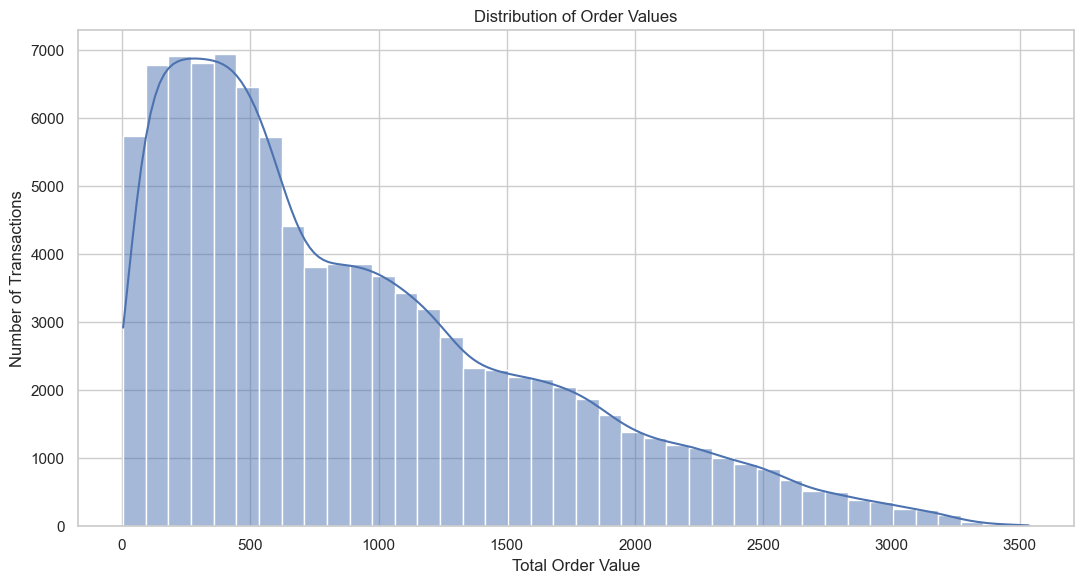

In [7]:
plt.figure(figsize=(11, 6))

sns.histplot(
    df["TotalAmount"],
    bins=40,
    kde=True
)

plt.title("Distribution of Order Values")
plt.xlabel("Total Order Value")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()


### Order Value Interpretation

The distribution helps identify whether order values are concentrated around a common range or whether a smaller number of high-value transactions create a long tail.

The chart should be interpreted together with the median and percentile statistics rather than relying only on the mean.


In [8]:
order_value_percentiles = (
    df["TotalAmount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename("TotalAmount")
    .reset_index()
    .rename(columns={"index": "Percentile"})
)

order_value_percentiles["Percentile"] = (
    order_value_percentiles["Percentile"] * 100
)

order_value_percentiles


,Percentile,TotalAmount
0,25.0,340.8900
1,50.0,714.3150
2,75.0,1349.7650
3,90.0,2009.1740
4,95.0,2383.6365
5,99.0,2947.8102


## 4. Order Status Analysis

The dataset's actual `OrderStatus` values are analyzed directly.

No status is assumed or reclassified without evidence from the dataset.


In [9]:
order_status_summary = (
    df.groupby("OrderStatus")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

order_status_summary["Order_Share_%"] = (
    order_status_summary["Orders"]
    / order_status_summary["Orders"].sum()
    * 100
)

order_status_summary["Sales_Share_%"] = (
    order_status_summary["NetProductSales"]
    / order_status_summary["NetProductSales"].sum()
    * 100
)

order_status_summary = order_status_summary.sort_values(
    "Orders",
    ascending=False
)

order_status_summary


,OrderStatus,Orders,Customers,Units,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Discount,Order_Share_%,Sales_Share_%
1,Delivered,74628,38772,223759,6.273130e+07,68372677.10,916.179947,0.074374,74.628,74.469045
4,Shipped,15192,13065,45660,1.291347e+07,14083628.99,927.042456,0.073654,15.192,15.329722
2,Pending,4103,3926,12338,3.431175e+06,3737556.98,910.932727,0.075640,4.103,4.073187
3,Returned,3049,2958,9141,2.549609e+06,2780662.46,911.991623,0.073188,3.049,3.026670
0,Cancelled,3028,2931,9242,2.612540e+06,2851122.39,941.585994,0.072573,3.028,3.101376


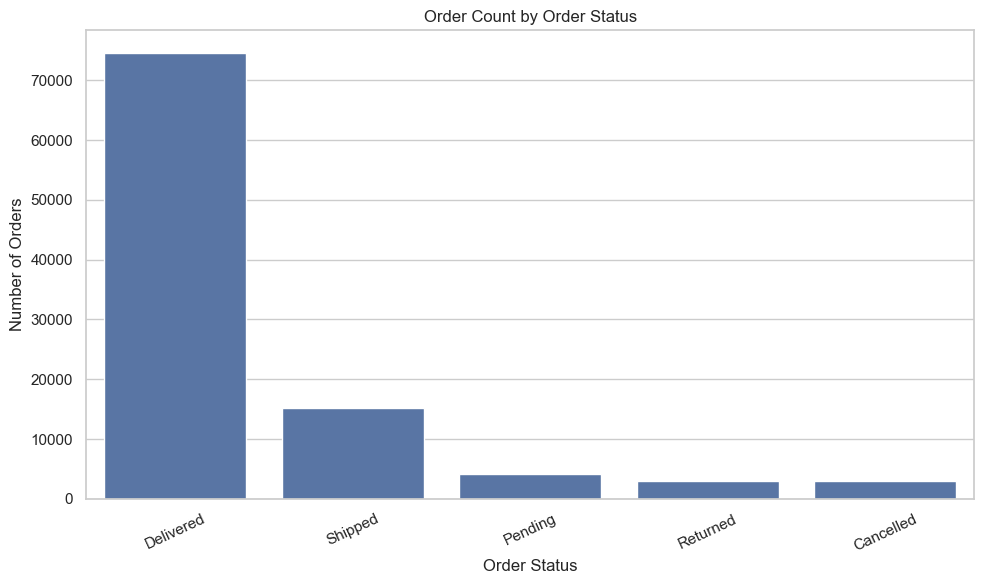

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=order_status_summary,
    x="OrderStatus",
    y="Orders"
)

plt.title("Order Count by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


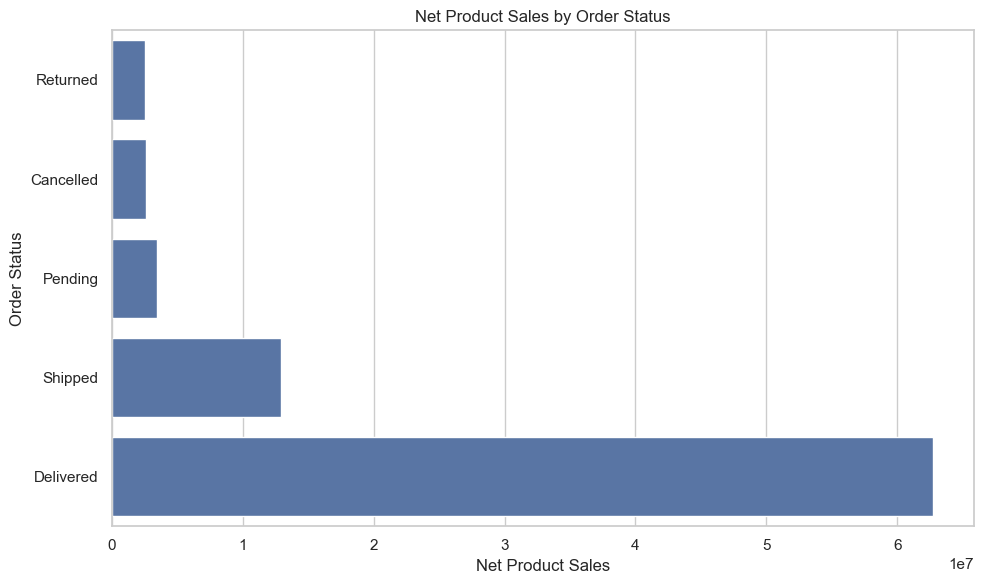

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=order_status_summary.sort_values("NetProductSales"),
    x="NetProductSales",
    y="OrderStatus"
)

plt.title("Net Product Sales by Order Status")
plt.xlabel("Net Product Sales")
plt.ylabel("Order Status")

plt.tight_layout()
plt.show()


## 5. Payment Method Overview

This section evaluates how customers use the available payment methods.


In [12]:
payment_summary = (
    df.groupby("PaymentMethod")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Median_Order_Value=("TotalAmount", "median"),
          Average_Discount=("Discount", "mean"),
          Products=("ProductID", "nunique"),
          Sellers=("SellerID", "nunique")
      )
      .reset_index()
)

payment_summary["Order_Share_%"] = (
    payment_summary["Orders"]
    / payment_summary["Orders"].sum()
    * 100
)

payment_summary["Sales_Share_%"] = (
    payment_summary["NetProductSales"]
    / payment_summary["NetProductSales"].sum()
    * 100
)

payment_summary = payment_summary.sort_values(
    "Orders",
    ascending=False
)

payment_summary


,PaymentMethod,Orders,Customers,Units,NetProductSales,TotalOrderValue,Average_Order_Value,Median_Order_Value,Average_Discount,Products,Sellers,Order_Share_%,Sales_Share_%
2,Credit Card,35038,25173,105046,2.946314e+07,32122158.69,916.780601,708.195,0.074301,50,1999,35.038,34.976032
3,Debit Card,20024,16545,60242,1.701741e+07,18538678.53,925.822939,724.800,0.073297,50,1999,20.024,20.201558
5,UPI,15066,13065,45218,1.275142e+07,13896028.55,922.343592,726.925,0.074373,50,1999,15.066,15.137355
0,Amazon Pay,15017,13022,45099,1.256792e+07,13697498.42,912.132811,704.970,0.074809,50,1996,15.017,14.919525
4,Net Banking,9927,8989,29699,8.295722e+06,9055674.57,912.226712,706.350,0.074856,50,1985,9.927,9.847946
1,Cash on Delivery,4928,4689,14836,4.142480e+06,4515609.16,916.316794,724.170,0.073975,50,1833,4.928,4.917585


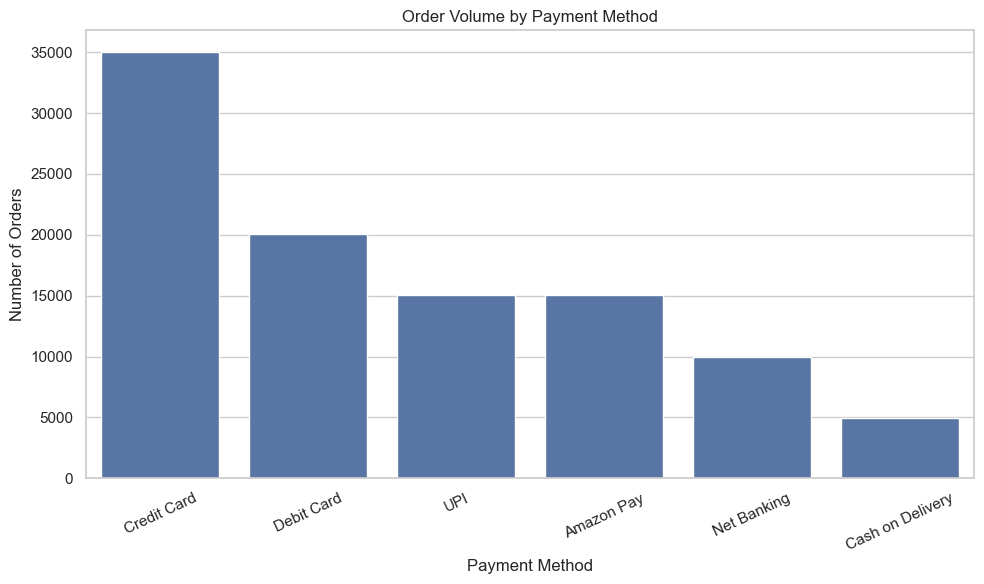

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_summary,
    x="PaymentMethod",
    y="Orders"
)

plt.title("Order Volume by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


## 6. Payment Method Sales Contribution

Order frequency and sales contribution can tell different stories.

This section compares payment methods by net product sales.


In [14]:
payment_sales = payment_summary.sort_values(
    "NetProductSales",
    ascending=False
)

payment_sales[
    [
        "PaymentMethod",
        "Orders",
        "Order_Share_%",
        "NetProductSales",
        "Sales_Share_%",
        "Average_Order_Value"
    ]
]


,PaymentMethod,Orders,Order_Share_%,NetProductSales,Sales_Share_%,Average_Order_Value
2,Credit Card,35038,35.038,2.946314e+07,34.976032,916.780601
3,Debit Card,20024,20.024,1.701741e+07,20.201558,925.822939
5,UPI,15066,15.066,1.275142e+07,15.137355,922.343592
0,Amazon Pay,15017,15.017,1.256792e+07,14.919525,912.132811
4,Net Banking,9927,9.927,8.295722e+06,9.847946,912.226712
1,Cash on Delivery,4928,4.928,4.142480e+06,4.917585,916.316794


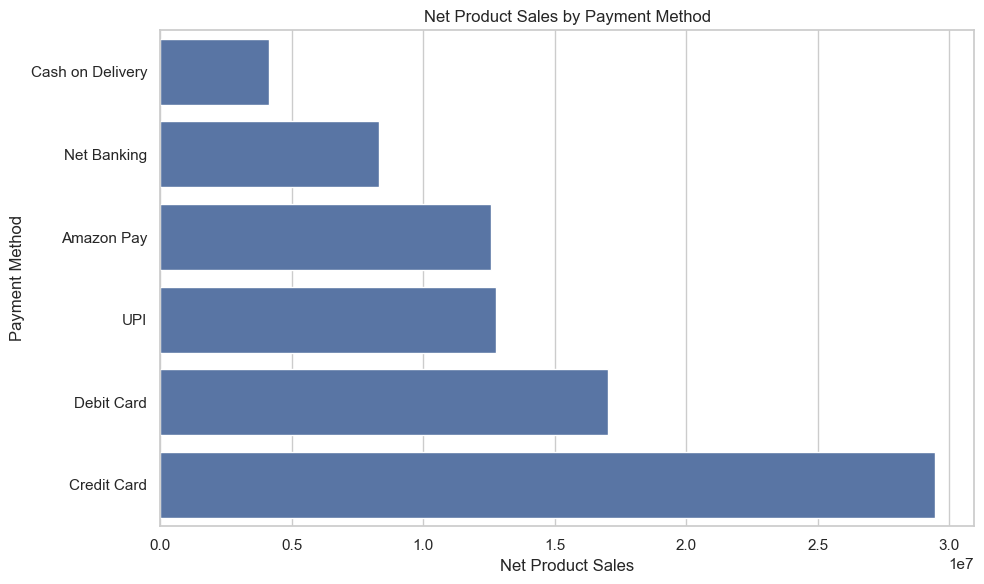

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_sales.sort_values("NetProductSales"),
    x="NetProductSales",
    y="PaymentMethod"
)

plt.title("Net Product Sales by Payment Method")
plt.xlabel("Net Product Sales")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()


## 7. Average Order Value by Payment Method

Average order value shows whether some payment methods are associated with higher-value transactions.


In [16]:
payment_aov = payment_summary.sort_values(
    "Average_Order_Value",
    ascending=False
)

payment_aov[
    [
        "PaymentMethod",
        "Average_Order_Value",
        "Median_Order_Value",
        "Orders",
        "NetProductSales"
    ]
]


,PaymentMethod,Average_Order_Value,Median_Order_Value,Orders,NetProductSales
3,Debit Card,925.822939,724.800,20024,1.701741e+07
5,UPI,922.343592,726.925,15066,1.275142e+07
2,Credit Card,916.780601,708.195,35038,2.946314e+07
1,Cash on Delivery,916.316794,724.170,4928,4.142480e+06
4,Net Banking,912.226712,706.350,9927,8.295722e+06
0,Amazon Pay,912.132811,704.970,15017,1.256792e+07


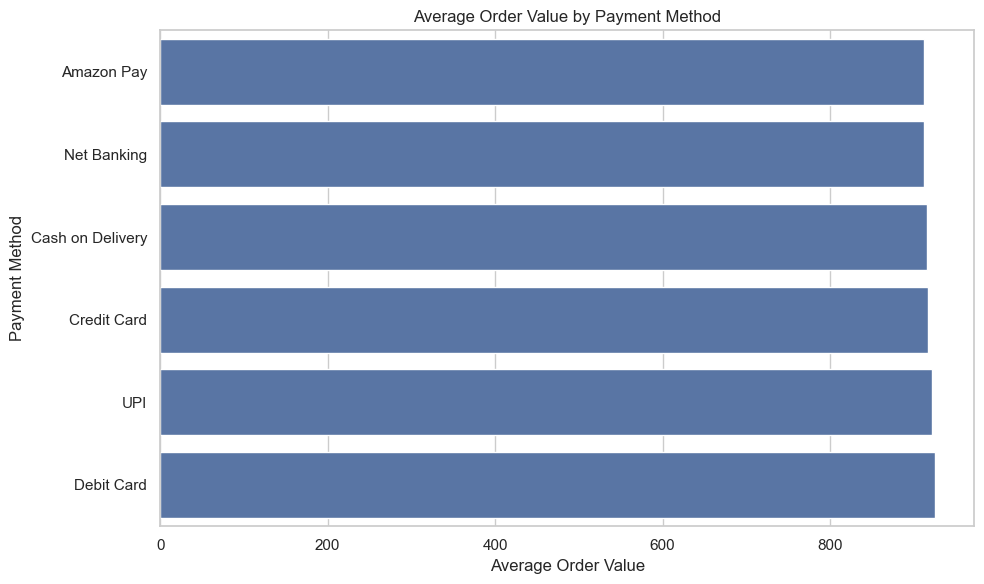

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_aov.sort_values("Average_Order_Value"),
    x="Average_Order_Value",
    y="PaymentMethod"
)

plt.title("Average Order Value by Payment Method")
plt.xlabel("Average Order Value")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()


## 8. Payment Method and Discount Behavior

This comparison checks whether different payment methods have different observed discount levels.

This is descriptive and does not establish that payment method causes discount differences.


In [18]:
payment_discount = payment_summary.sort_values(
    "Average_Discount",
    ascending=False
)

payment_discount[
    [
        "PaymentMethod",
        "Average_Discount",
        "Orders",
        "NetProductSales",
        "Average_Order_Value"
    ]
]


,PaymentMethod,Average_Discount,Orders,NetProductSales,Average_Order_Value
4,Net Banking,0.074856,9927,8.295722e+06,912.226712
0,Amazon Pay,0.074809,15017,1.256792e+07,912.132811
5,UPI,0.074373,15066,1.275142e+07,922.343592
2,Credit Card,0.074301,35038,2.946314e+07,916.780601
1,Cash on Delivery,0.073975,4928,4.142480e+06,916.316794
3,Debit Card,0.073297,20024,1.701741e+07,925.822939


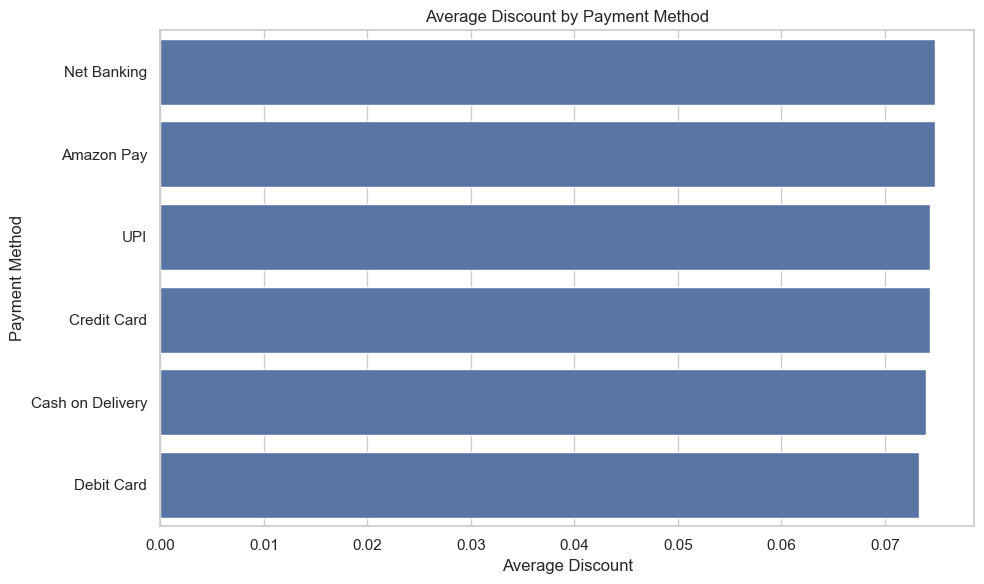

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_discount,
    x="Average_Discount",
    y="PaymentMethod"
)

plt.title("Average Discount by Payment Method")
plt.xlabel("Average Discount")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()


## 9. Payment Method × Order Status

The cross-tabulation below shows how order statuses are distributed across payment methods.


In [20]:
payment_status_count = pd.crosstab(
    df["PaymentMethod"],
    df["OrderStatus"]
)

payment_status_count


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Amazon Pay,461,11251,585,472,2248
Cash on Delivery,156,3633,196,143,800
Credit Card,1083,26073,1471,1075,5336
Debit Card,593,14917,832,609,3073
Net Banking,291,7406,417,313,1500
UPI,444,11348,602,437,2235


In [21]:
payment_status_percentage = (
    pd.crosstab(
        df["PaymentMethod"],
        df["OrderStatus"],
        normalize="index"
    )
    * 100
)

payment_status_percentage


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Amazon Pay,3.069854,74.921755,3.895585,3.143104,14.969701
Cash on Delivery,3.165584,73.721591,3.977273,2.901786,16.233766
Credit Card,3.090930,74.413494,4.198299,3.068097,15.229180
Debit Card,2.961446,74.495605,4.155014,3.041350,15.346584
Net Banking,2.931399,74.604614,4.200665,3.153017,15.110305
UPI,2.947033,75.321917,3.995752,2.900571,14.834727


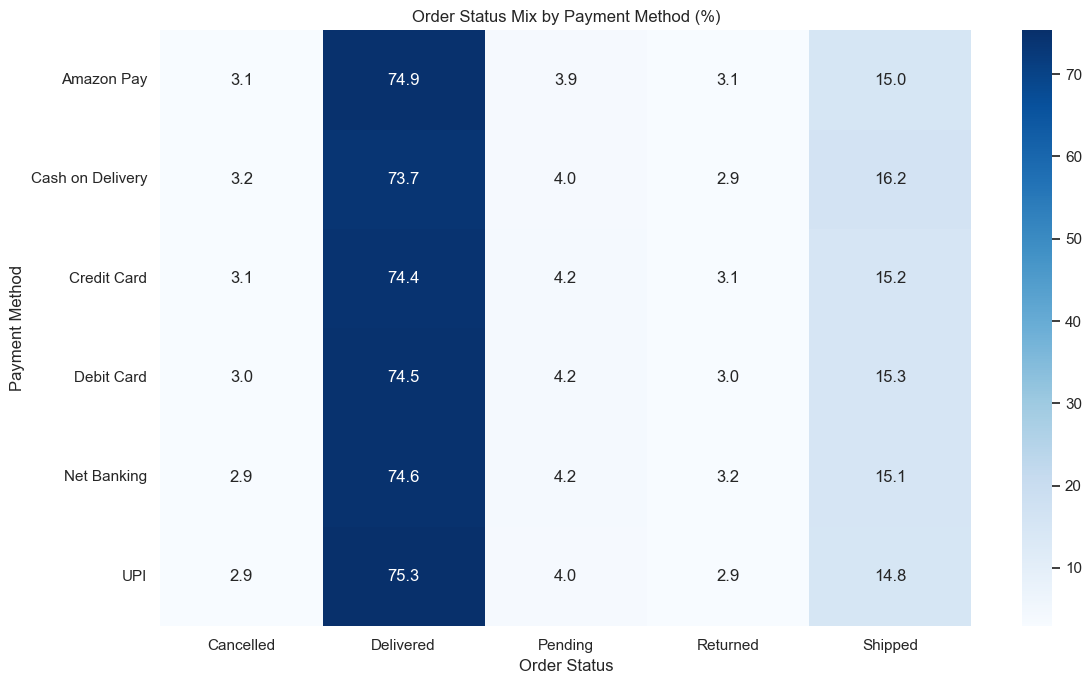

In [22]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    payment_status_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Order Status Mix by Payment Method (%)")
plt.xlabel("Order Status")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()


## 10. Payment Method × Customer Analysis

This section measures customer reach and the number of payment methods used by individual customers.


In [23]:
customer_payment_count = (
    df.groupby("CustomerID")["PaymentMethod"]
      .nunique()
      .rename("Unique_Payment_Methods")
      .reset_index()
)

customer_payment_count["Unique_Payment_Methods"].value_counts().sort_index()


Unique_Payment_Methods
1    17173
2    16269
3     7645
4     1901
5      237
6        8
Name: count, dtype: int64

In [24]:
customer_payment_summary = (
    df.groupby("CustomerID")
      .agg(
          Orders=("OrderID", "nunique"),
          Payment_Methods=("PaymentMethod", "nunique"),
          Total_Order_Value=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
)

customer_payment_summary.head(10)


,CustomerID,Orders,Payment_Methods,Total_Order_Value,Average_Order_Value
0,CUST000001,1,1,446.48,446.480000
1,CUST000002,3,2,1389.93,463.310000
2,CUST000003,1,1,1116.91,1116.910000
3,CUST000004,3,3,2660.06,886.686667
4,CUST000005,1,1,1089.56,1089.560000
5,CUST000006,4,2,2831.85,707.962500
6,CUST000007,1,1,450.53,450.530000
7,CUST000008,3,3,4116.16,1372.053333
8,CUST000009,2,1,2120.69,1060.345000
9,CUST000010,2,2,1201.00,600.500000


## 11. Payment Method by Country

This analysis identifies payment-method preferences across geographic markets.

It does not infer why a payment method is preferred.


In [25]:
country_payment = pd.crosstab(
    df["Country"],
    df["PaymentMethod"]
)

country_payment


PaymentMethod,Amazon Pay,Cash on Delivery,Credit Card,Debit Card,Net Banking,UPI
Country,,,,,,
Australia,619,219,1475,844,386,587
Canada,850,295,2018,1178,600,877
India,2257,780,5223,2996,1492,2303
United Kingdom,732,229,1737,1004,474,767
United States,10559,3405,24585,14002,6975,10532


In [26]:
country_payment_percentage = (
    pd.crosstab(
        df["Country"],
        df["PaymentMethod"],
        normalize="index"
    )
    * 100
)

country_payment_percentage


PaymentMethod,Amazon Pay,Cash on Delivery,Credit Card,Debit Card,Net Banking,UPI
Country,,,,,,
Australia,14.987893,5.302663,35.714286,20.435835,9.346247,14.213075
Canada,14.609832,5.070471,34.685459,20.247508,10.312822,15.073909
India,14.995681,5.182380,34.702013,19.905654,9.912963,15.301309
United Kingdom,14.808821,4.632814,35.140603,20.311552,9.589318,15.516893
United States,15.071798,4.860259,35.092352,19.986297,9.956036,15.033258


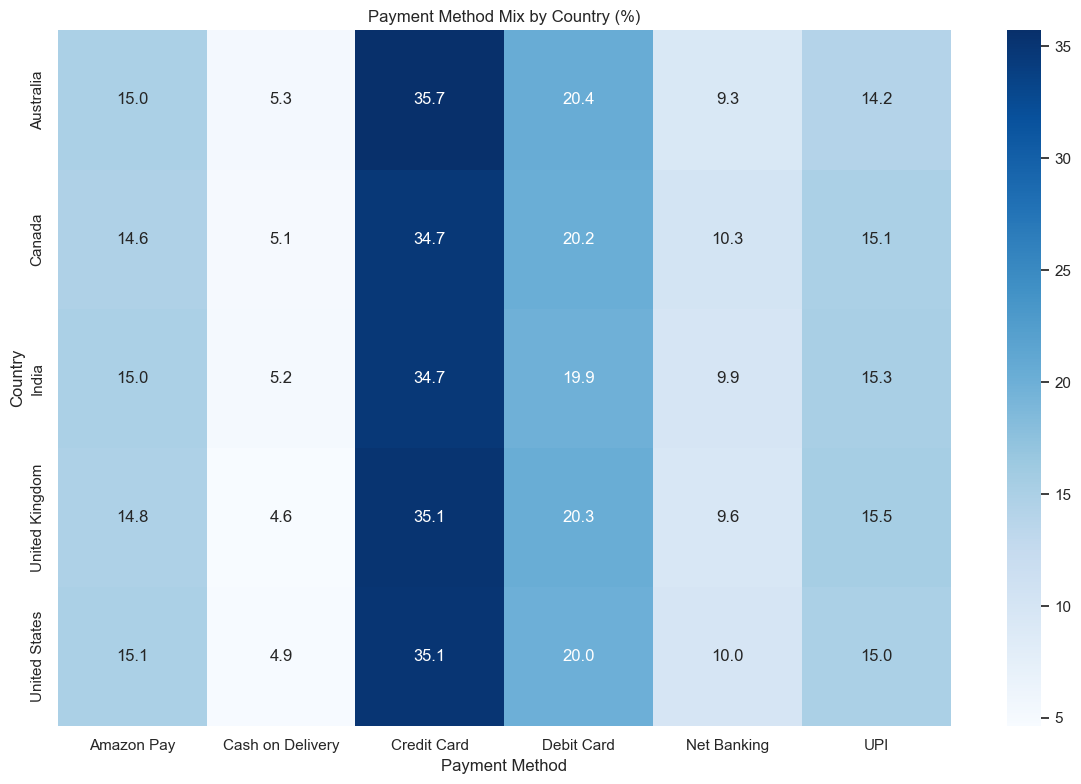

In [27]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    country_payment_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Payment Method Mix by Country (%)")
plt.xlabel("Payment Method")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


## 12. Top Payment Method in Each Country

The following table identifies the most frequently used payment method in each country.


In [28]:
country_payment_counts = (
    df.groupby(["Country", "PaymentMethod"])
      .agg(
          Orders=("OrderID", "nunique"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

top_payment_by_country = (
    country_payment_counts
    .sort_values(
        ["Country", "Orders"],
        ascending=[True, False]
    )
    .groupby("Country")
    .head(1)
    .reset_index(drop=True)
)

top_payment_by_country


,Country,PaymentMethod,Orders,NetProductSales
0,Australia,Credit Card,1475,1.247293e+06
1,Canada,Credit Card,2018,1.681296e+06
2,India,Credit Card,5223,4.394495e+06
3,United Kingdom,Credit Card,1737,1.427062e+06
4,United States,Credit Card,24585,2.071300e+07


## 13. Payment Method by Seller

This section identifies which sellers receive the highest order volume through each payment method.


In [29]:
seller_payment_summary = (
    df.groupby(["SellerID", "PaymentMethod"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum")
      )
      .reset_index()
)

top_seller_by_payment = (
    seller_payment_summary
    .sort_values(
        ["PaymentMethod", "Orders"],
        ascending=[True, False]
    )
    .groupby("PaymentMethod")
    .head(1)
    .reset_index(drop=True)
)

top_seller_by_payment


,SellerID,PaymentMethod,Orders,Customers,NetProductSales,TotalOrderValue
0,SELL01357,Amazon Pay,18,18,17575.4725,19168.98
1,SELL01774,Cash on Delivery,9,9,4184.0965,4553.02
2,SELL00306,Credit Card,33,33,32610.8585,35772.75
3,SELL00371,Debit Card,21,21,23041.0175,25912.91
4,SELL01841,Net Banking,14,14,13270.7165,14767.14
5,SELL01889,UPI,18,18,11713.7010,12912.76


## 14. Daily Order Activity

Daily order volume helps identify periods of unusually high or low transaction activity.


In [30]:
daily_orders = (
    df.groupby(df["OrderDate"].dt.date)
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum")
      )
      .reset_index()
      .rename(columns={"OrderDate": "Date"})
)

daily_orders["Date"] = pd.to_datetime(daily_orders["Date"])

daily_orders.head()


,Date,Orders,Customers,Units,NetProductSales,TotalOrderValue
0,2020-01-01,62,62,164,49808.7995,55180.39
1,2020-01-02,46,46,132,41756.0720,45415.31
2,2020-01-03,47,47,146,37799.5165,40744.16
3,2020-01-04,59,59,197,52849.3850,58572.99
4,2020-01-05,48,47,141,39744.3750,43502.13


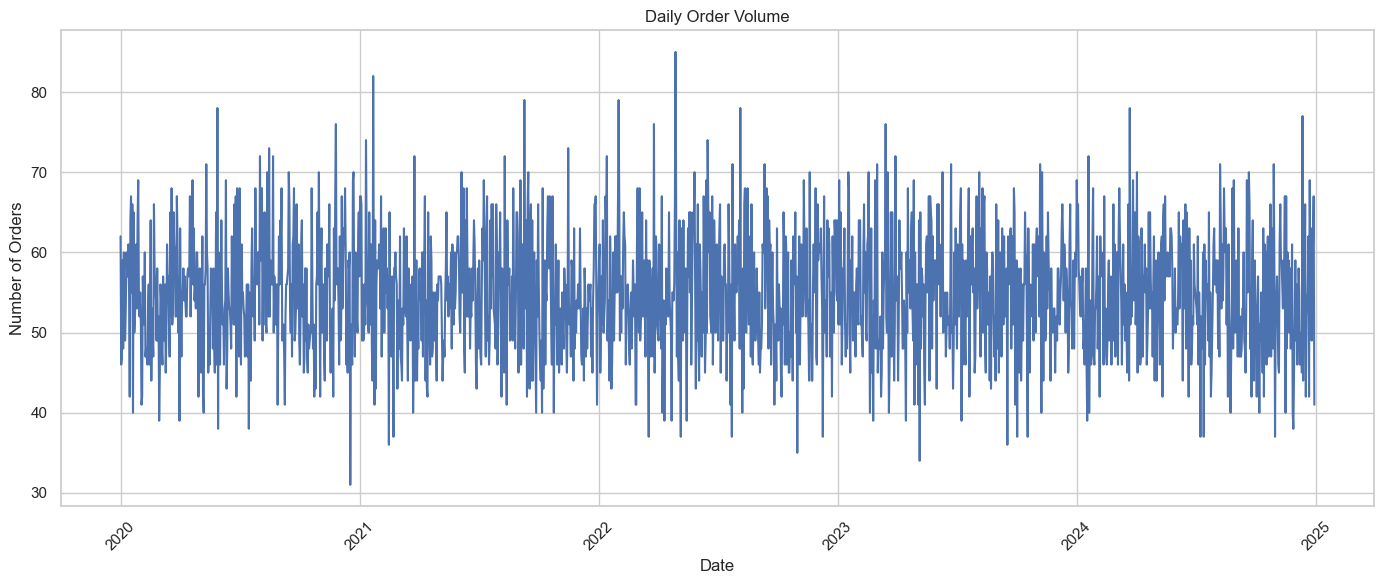

In [31]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_orders,
    x="Date",
    y="Orders"
)

plt.title("Daily Order Volume")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 15. Daily Sales Activity

Daily net product sales are compared with order volume to identify high-value transaction periods.


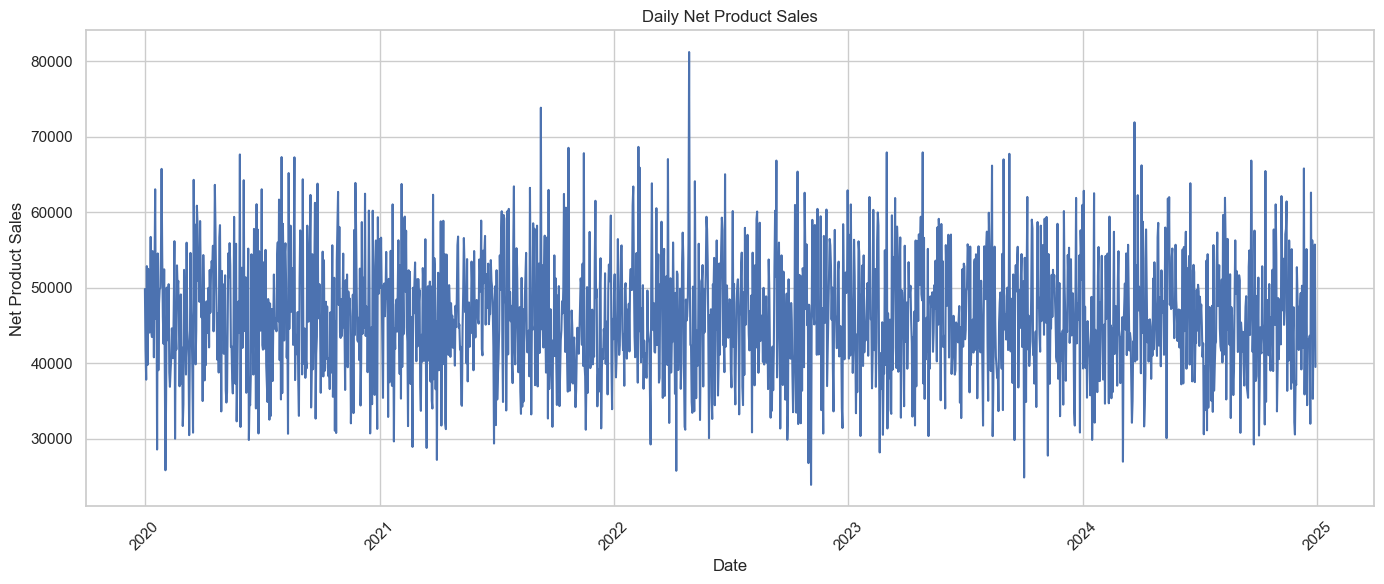

In [32]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_orders,
    x="Date",
    y="NetProductSales"
)

plt.title("Daily Net Product Sales")
plt.xlabel("Date")
plt.ylabel("Net Product Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 16. Monthly Order Analysis

Monthly aggregation provides a higher-level view of order activity over time.

The notebook derives the month directly from `OrderDate`.


In [33]:
df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)

monthly_orders = (
    df.groupby("OrderMonth")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
)

monthly_orders


,OrderMonth,Orders,Customers,Units,NetProductSales,TotalOrderValue,Average_Order_Value
0,2020-01,1730,1697,5225,1.500637e+06,1637069.40,946.282890
1,2020-02,1490,1473,4343,1.228819e+06,1339388.21,898.918262
2,2020-03,1685,1653,5050,1.454230e+06,1587125.66,941.914338
3,2020-04,1692,1666,5156,1.456791e+06,1588347.29,938.739533
4,2020-05,1672,1639,5061,1.407329e+06,1533834.17,917.364934
5,2020-06,1633,1610,4883,1.375679e+06,1500269.29,918.719712
6,2020-07,1687,1652,5061,1.424383e+06,1552981.94,920.558352
7,2020-08,1783,1753,5439,1.506393e+06,1640874.93,920.288800
8,2020-09,1679,1649,5023,1.427199e+06,1554682.21,925.957242
9,2020-10,1647,1621,4908,1.390415e+06,1515403.62,920.099344


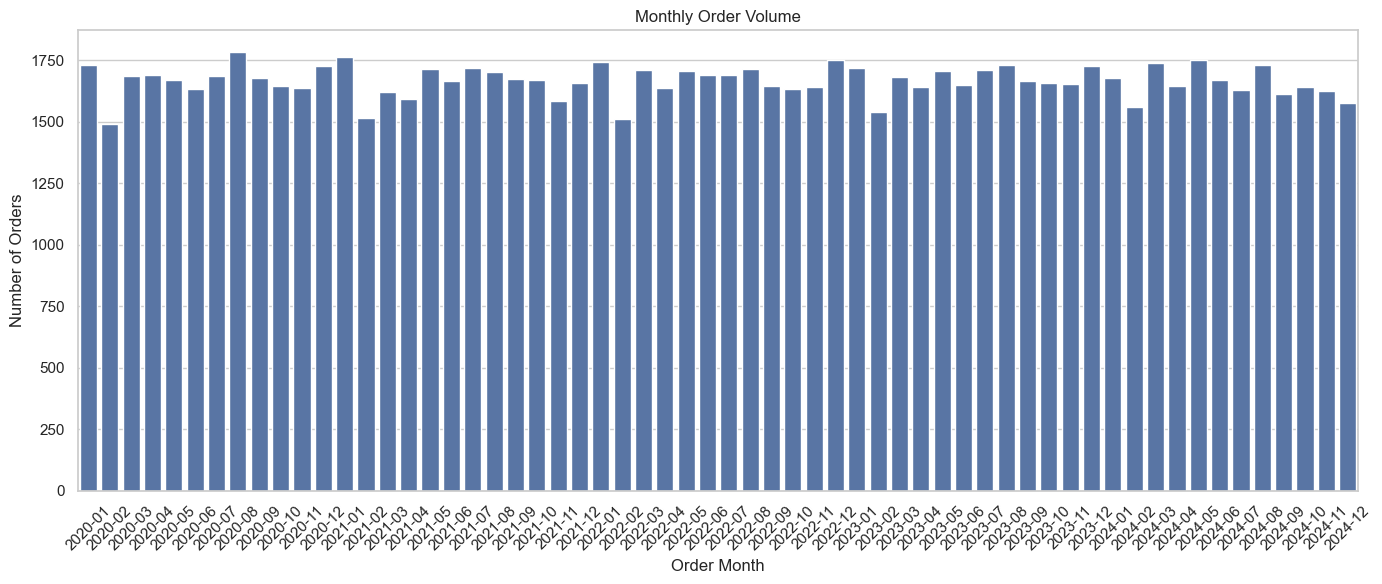

In [34]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=monthly_orders,
    x="OrderMonth",
    y="Orders",
    ax=ax
)

ax.set_title("Monthly Order Volume")
ax.set_xlabel("Order Month")
ax.set_ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 17. Monthly Payment Method Trends

This section shows whether payment method usage changes over time.


In [35]:
monthly_payment = (
    df.groupby(["OrderMonth", "PaymentMethod"])
      .agg(
          Orders=("OrderID", "nunique"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

monthly_payment.head()


,OrderMonth,PaymentMethod,Orders,NetProductSales
0,2020-01,Amazon Pay,266,220855.0305
1,2020-01,Cash on Delivery,75,75853.2815
2,2020-01,Credit Card,603,517978.7305
3,2020-01,Debit Card,343,310218.1830
4,2020-01,Net Banking,161,121271.3785


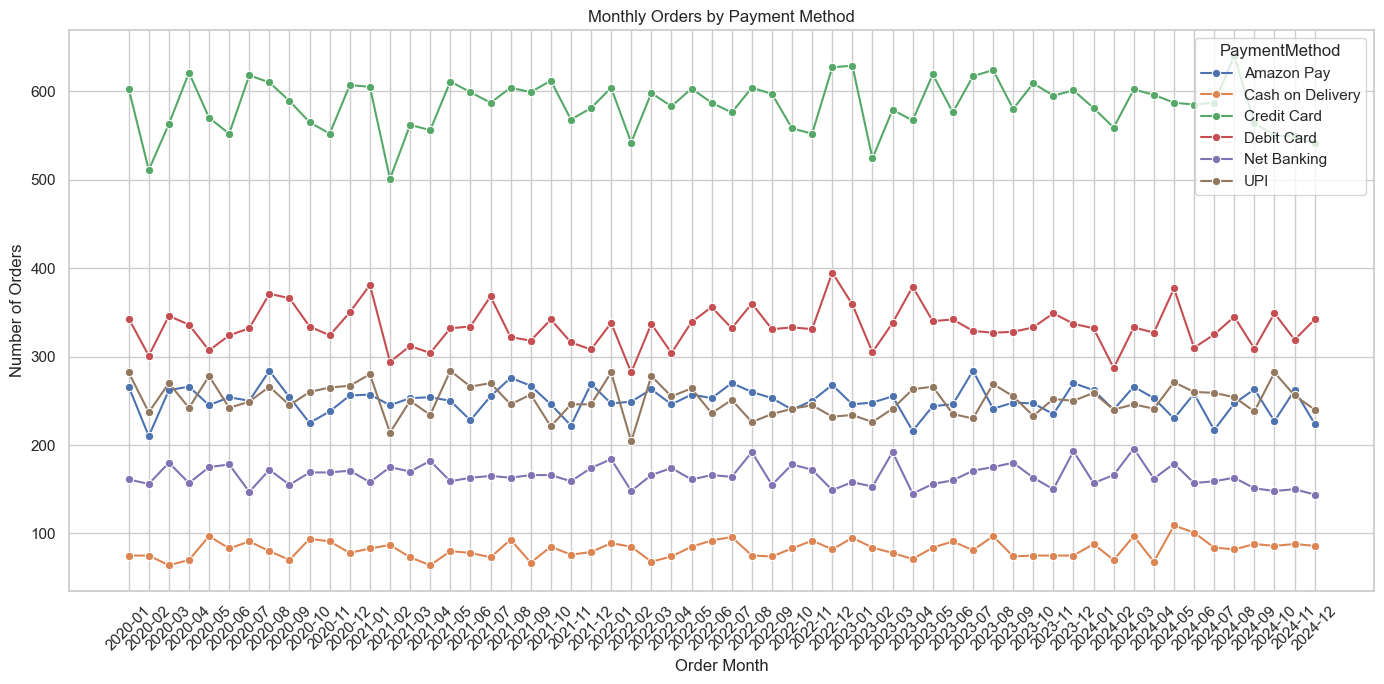

In [36]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_payment,
    x="OrderMonth",
    y="Orders",
    hue="PaymentMethod",
    marker="o"
)

plt.title("Monthly Orders by Payment Method")
plt.xlabel("Order Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 18. High-Value Orders

The highest-value transactions are identified to understand the characteristics of unusually large orders.

This is an exploratory ranking, not a fraud-detection model.


In [37]:
high_value_orders = (
    df[
        [
            "OrderID",
            "OrderDate",
            "CustomerID",
            "PaymentMethod",
            "OrderStatus",
            "Country",
            "City",
            "SellerID",
            "Quantity",
            "Discount",
            "TotalAmount",
            "NetProductSales"
        ]
    ]
    .sort_values("TotalAmount", ascending=False)
    .drop_duplicates("OrderID")
    .head(20)
)

high_value_orders


,OrderID,OrderDate,CustomerID,PaymentMethod,OrderStatus,Country,City,SellerID,Quantity,Discount,TotalAmount,NetProductSales
48442,ORD0048443,2020-01-12,CUST010794,Amazon Pay,Shipped,India,San Diego,SELL00471,5,0.0,3534.98,2991.45
81886,ORD0081887,2020-09-26,CUST031626,UPI,Shipped,United States,Denver,SELL00354,5,0.0,3521.85,2982.35
4196,ORD0004197,2021-02-22,CUST022868,Credit Card,Delivered,United States,San Francisco,SELL00601,5,0.0,3514.24,2976.30
1929,ORD0001930,2023-08-18,CUST031209,UPI,Delivered,United Kingdom,Phoenix,SELL00955,5,0.0,3513.65,2974.25
58204,ORD0058205,2021-10-19,CUST033287,UPI,Delivered,United States,San Antonio,SELL01072,5,0.0,3513.05,2972.30
46764,ORD0046765,2024-04-13,CUST044400,Net Banking,Shipped,United States,Los Angeles,SELL01587,5,0.0,3511.95,2974.10
40146,ORD0040147,2024-10-07,CUST001991,Cash on Delivery,Delivered,United States,Los Angeles,SELL01921,5,0.0,3510.23,2966.50
20578,ORD0020579,2023-09-24,CUST016754,Amazon Pay,Delivered,United States,San Diego,SELL00531,5,0.0,3509.30,2969.70
95429,ORD0095430,2023-03-08,CUST001586,Net Banking,Shipped,Australia,Jacksonville,SELL00956,5,0.0,3499.15,2957.75
51547,ORD0051548,2024-03-22,CUST024376,Net Banking,Delivered,India,San Jose,SELL00222,5,0.0,3498.13,2955.45


## 19. Payment Method and High-Value Orders

The payment method distribution among the highest-value orders is compared with the overall payment distribution.

No fraud conclusion is made from this comparison.


In [38]:
high_value_threshold = df["TotalAmount"].quantile(0.90)

df["High_Value_Order"] = (
    df["TotalAmount"] >= high_value_threshold
)

high_value_payment = (
    df[df["High_Value_Order"]]
    .groupby("PaymentMethod")
    .agg(
        Orders=("OrderID", "nunique"),
        NetProductSales=("NetProductSales", "sum"),
        Average_Order_Value=("TotalAmount", "mean")
    )
    .reset_index()
    .sort_values("Orders", ascending=False)
)

print(f"90th percentile order-value threshold: {high_value_threshold:,.2f}")

high_value_payment


90th percentile order-value threshold: 2,009.17


,PaymentMethod,Orders,NetProductSales,Average_Order_Value
2,Credit Card,3501,7.876036e+06,2452.584727
3,Debit Card,2036,4.599397e+06,2457.713040
5,UPI,1507,3.388021e+06,2449.301500
0,Amazon Pay,1492,3.354854e+06,2449.252808
4,Net Banking,973,2.184351e+06,2454.487061
1,Cash on Delivery,491,1.086914e+06,2417.330591


## 20. Order Status × Payment Method Sales

This table combines transaction outcome and payment method to show where monetary activity is concentrated.


In [39]:
status_payment_sales = (
    df.groupby(["OrderStatus", "PaymentMethod"])
      .agg(
          Orders=("OrderID", "nunique"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
      .sort_values("NetProductSales", ascending=False)
)

status_payment_sales.head(30)


,OrderStatus,PaymentMethod,Orders,NetProductSales,TotalOrderValue,Average_Order_Value
8,Delivered,Credit Card,26073,2.195354e+07,23933235.36,917.931782
9,Delivered,Debit Card,14917,1.264273e+07,13766755.60,922.890367
11,Delivered,UPI,11348,9.536083e+06,10391992.94,915.755458
6,Delivered,Amazon Pay,11251,9.426529e+06,10272833.59,913.059603
10,Delivered,Net Banking,7406,6.141458e+06,6702679.86,905.033738
26,Shipped,Credit Card,5336,4.468950e+06,4876349.21,913.858548
7,Delivered,Cash on Delivery,3633,3.030963e+06,3305179.75,909.765965
27,Shipped,Debit Card,3073,2.653518e+06,2896864.37,942.682841
29,Shipped,UPI,2235,1.946313e+06,2118982.49,948.090600
24,Shipped,Amazon Pay,2248,1.889525e+06,2060762.89,916.709471


## 21. Payment Method Correlation with Order Value

Payment methods are categorical, so correlation should not be interpreted directly between payment labels and order values.

Instead, the analysis compares descriptive order-value statistics by payment method.


In [40]:
payment_order_value_stats = (
    df.groupby("PaymentMethod")["TotalAmount"]
      .agg(
          ["count", "mean", "median", "min", "max", "std"]
      )
      .reset_index()
      .rename(columns={
          "count": "Transactions",
          "mean": "Mean_Order_Value",
          "median": "Median_Order_Value",
          "min": "Minimum_Order_Value",
          "max": "Maximum_Order_Value",
          "std": "Std_Order_Value"
      })
)

payment_order_value_stats


,PaymentMethod,Transactions,Mean_Order_Value,Median_Order_Value,Minimum_Order_Value,Maximum_Order_Value,Std_Order_Value
0,Amazon Pay,15017,912.132811,704.970,5.59,3534.98,724.071748
1,Cash on Delivery,4928,916.316794,724.170,6.52,3510.23,714.061182
2,Credit Card,35038,916.780601,708.195,7.05,3514.24,725.144081
3,Debit Card,20024,925.822939,724.800,6.19,3491.32,728.423816
4,Net Banking,9927,912.226712,706.350,4.27,3511.95,722.904882
5,UPI,15066,922.343592,726.925,6.19,3521.85,722.700646


## 22. Direct Business Answers

The following cells provide direct answers to the main order and payment questions.


In [41]:
most_used_payment = payment_summary.loc[
    payment_summary["Orders"].idxmax()
]

highest_payment_sales = payment_summary.loc[
    payment_summary["NetProductSales"].idxmax()
]

highest_payment_aov = payment_summary.loc[
    payment_summary["Average_Order_Value"].idxmax()
]

most_common_status = order_status_summary.loc[
    order_status_summary["Orders"].idxmax()
]

highest_status_sales = order_status_summary.loc[
    order_status_summary["NetProductSales"].idxmax()
]

highest_value_order = df.loc[
    df["TotalAmount"].idxmax()
]

print(
    f"Most-used payment method: {most_used_payment['PaymentMethod']} "
    f"({int(most_used_payment['Orders']):,} orders)"
)

print(
    f"Payment method with highest net product sales: "
    f"{highest_payment_sales['PaymentMethod']} "
    f"(${highest_payment_sales['NetProductSales']:,.2f})"
)

print(
    f"Payment method with highest average order value: "
    f"{highest_payment_aov['PaymentMethod']} "
    f"(${highest_payment_aov['Average_Order_Value']:,.2f})"
)

print(
    f"Most common order status: {most_common_status['OrderStatus']} "
    f"({int(most_common_status['Orders']):,} orders)"
)

print(
    f"Order status with highest net product sales: "
    f"{highest_status_sales['OrderStatus']} "
    f"(${highest_status_sales['NetProductSales']:,.2f})"
)

print(
    f"Highest recorded transaction value: "
    f"${highest_value_order['TotalAmount']:,.2f} "
    f"(Order ID: {highest_value_order['OrderID']})"
)


Most-used payment method: Credit Card (35,038 orders)
Payment method with highest net product sales: Credit Card ($29,463,142.45)
Payment method with highest average order value: Debit Card ($925.82)
Most common order status: Delivered (74,628 orders)
Order status with highest net product sales: Delivered ($62,731,303.56)
Highest recorded transaction value: $3,534.98 (Order ID: ORD0048443)


## 23. Final Order & Payment Insights

### Order Behavior
The order-value distribution shows the typical and high-value transaction ranges in the dataset.

### Order Status
Status analysis identifies the dominant recorded order outcomes and their contribution to transaction activity.

### Payment Adoption
Payment-method rankings show which payment options customers use most frequently.

### Payment Sales Contribution
The most frequently used payment method is not necessarily the payment method generating the highest sales value.

### Average Order Value
Comparing average and median order value by payment method provides a clearer picture of transaction-value differences.

### Geographic Payment Patterns
Country-level payment analysis identifies differences in payment-method mix across markets.

### Seller Payment Patterns
Seller-level payment analysis shows which sellers receive the greatest order activity through each payment method.

### Time Trends
Daily and monthly analysis identifies changes in order activity and payment-method usage over time.

### High-Value Transactions
High-value orders are highlighted for business monitoring, but the dataset does not contain sufficient fields to determine whether any transaction is fraudulent or abnormal.

### Data Limitation
The dataset does not include payment gateway, transaction failure reason, refund amount, chargeback, fraud label, payment processing fee, or payment provider information. Therefore, this notebook evaluates payment usage and transaction patterns rather than payment risk or payment profitability.


## 24. Export Order & Payment Analysis Outputs

The main analytical tables are exported for reuse in the final business-insights and dashboard stages.


In [42]:
output_dir = Path("../data/order_payment_analysis_outputs")

output_dir.mkdir(parents=True, exist_ok=True)

order_overview.to_csv(
    output_dir / "order_overview.csv",
    index=False
)

order_status_summary.to_csv(
    output_dir / "order_status_summary.csv",
    index=False
)

payment_summary.to_csv(
    output_dir / "payment_summary.csv",
    index=False
)

payment_status_count.to_csv(
    output_dir / "payment_status_count.csv"
)

payment_status_percentage.to_csv(
    output_dir / "payment_status_percentage.csv"
)

country_payment.to_csv(
    output_dir / "country_payment_count.csv"
)

country_payment_percentage.to_csv(
    output_dir / "country_payment_percentage.csv"
)

top_payment_by_country.to_csv(
    output_dir / "top_payment_by_country.csv",
    index=False
)

seller_payment_summary.to_csv(
    output_dir / "seller_payment_summary.csv",
    index=False
)

top_seller_by_payment.to_csv(
    output_dir / "top_seller_by_payment.csv",
    index=False
)

daily_orders.to_csv(
    output_dir / "daily_orders.csv",
    index=False
)

monthly_orders.to_csv(
    output_dir / "monthly_orders.csv",
    index=False
)

monthly_payment.to_csv(
    output_dir / "monthly_payment_trends.csv",
    index=False
)

high_value_orders.to_csv(
    output_dir / "high_value_orders.csv",
    index=False
)

high_value_payment.to_csv(
    output_dir / "high_value_payment_methods.csv",
    index=False
)

status_payment_sales.to_csv(
    output_dir / "status_payment_sales.csv",
    index=False
)

payment_order_value_stats.to_csv(
    output_dir / "payment_order_value_stats.csv",
    index=False
)

print("Order and payment analysis outputs exported successfully.")
print("Output directory:", output_dir)


Order and payment analysis outputs exported successfully.
Output directory: ..\data\order_payment_analysis_outputs


# 25. Conclusion

This notebook provided a structured analysis of order behavior and payment patterns across the e-commerce dataset.

The analysis covered:

- Overall order activity
- Order-value distribution
- Order-status performance
- Payment-method adoption
- Payment-method sales contribution
- Average order value by payment method
- Payment-method discount behavior
- Payment method × order status
- Payment method × country
- Payment method × seller
- Daily and monthly order trends
- Monthly payment-method trends
- High-value transaction analysis
- Business questions and insights

The results complement the previous Sales, Product, Customer, Discount, Seller, and Geographic analyses.